In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
BASE = "/kaggle/input/datasets/varun000reddy"

train_img_dir = f"{BASE}/training/train/image"
train_ann_dir = f"{BASE}/training/train/annos"

val_img_dir = f"{BASE}/validation/validation/image"
val_ann_dir = f"{BASE}/validation/validation/annos"

In [2]:
import os, json, random
from collections import Counter

ann_files = os.listdir(train_ann_dir)

#  sample only 5000 files (FAST + accurate enough)
sample_files = random.sample(ann_files, min(5000, len(ann_files)))

category_counter = Counter()

for file in sample_files:
    with open(os.path.join(train_ann_dir, file)) as f:
        data = json.load(f)

        for item in data.values():
            if isinstance(item, dict) and "category_name" in item:
                category_counter[item["category_name"]] += 1

top5_classes = [x[0] for x in category_counter.most_common(5)]

print("Top 5 classes:", top5_classes)

Top 5 classes: ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']


In [5]:
import os, json
import numpy as np

BASE = "/kaggle/input/datasets/varun000reddy"

train_img_dir = f"{BASE}/training/train/image"
train_ann_dir = f"{BASE}/training/train/annos"

val_img_dir = f"{BASE}/validation/validation/image"
val_ann_dir = f"{BASE}/validation/validation/annos"

label_map = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

num_classes = len(label_map)

In [6]:
def load_data(img_dir, ann_dir):
    data = []

    for file in os.listdir(img_dir):
        img_path = os.path.join(img_dir, file)
        ann_path = os.path.join(ann_dir, file.replace(".jpg", ".json"))

        if not os.path.exists(ann_path):
            continue

        label = np.zeros(num_classes)

        with open(ann_path) as f:
            ann = json.load(f)

            for item in ann.values():
                if isinstance(item, dict) and "category_name" in item:
                    cls = item["category_name"]
                    if cls in label_map:
                        label[label_map[cls]] = 1

        if label.sum() > 0:
            data.append((img_path, label))

    return data

In [7]:
def load_data(img_dir, ann_dir, max_samples=10000):
    data = []

    files = os.listdir(img_dir)

    for file in files:
        if len(data) >= max_samples:
            break

        img_path = os.path.join(img_dir, file)
        ann_path = os.path.join(ann_dir, file.replace(".jpg", ".json"))

        if not os.path.exists(ann_path):
            continue

        label = np.zeros(num_classes)

        with open(ann_path) as f:
            ann = json.load(f)

            for item in ann.values():
                if isinstance(item, dict) and "category_name" in item:
                    cls = item["category_name"]
                    if cls in label_map:
                        label[label_map[cls]] = 1

        if label.sum() > 0:
            data.append((img_path, label))

    return data

In [8]:
train_data = load_data(train_img_dir, train_ann_dir, max_samples=10000)
val_data   = load_data(val_img_dir, val_ann_dir, max_samples=2000)

print(len(train_data), len(val_data))

10000 2000


5A. Dataset + DataLoader

In [9]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [10]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class FashionDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [11]:
train_dataset = FashionDataset(train_data, transform=train_transform)
val_dataset   = FashionDataset(val_data, transform=val_transform)

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[0])

torch.Size([32, 3, 224, 224])
torch.Size([32, 5])
tensor([0., 0., 1., 0., 0.])


STEP 7: MobileNet + Class Weight

In [14]:
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v3_small(pretrained=True)

# modify final layer for 5 classes
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 143MB/s]


In [16]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(device)

cuda


In [17]:
import torch

# collect labels
all_labels = torch.tensor([label for _, label in train_data])

# compute pos_weight
pos_weight = (len(all_labels) - all_labels.sum(dim=0)) / all_labels.sum(dim=0)
pos_weight = pos_weight.float().to(device)

print("Class weights:", pos_weight)

Class weights: tensor([1.0375, 1.6096, 2.9463, 3.0323, 3.8239], device='cuda:0')


In [19]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

**Training From Scratch** 

In [22]:
import torchvision.models as models
import torch.nn as nn

model_scratch = models.mobilenet_v3_small(weights=None)  # ❗ from scratch
model_scratch.classifier[3] = nn.Linear(
    model_scratch.classifier[3].in_features, 5
)
model_scratch = model_scratch.to(device)

In [23]:
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

In [26]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [28]:
# Evaluation Function
from sklearn.metrics import f1_score
import torch

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu()

            preds.append(outputs)
            targets.append(labels)

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    preds = (preds > 0.5).astype(int)

    return f1_score(targets, preds, average="macro")

In [29]:
for epoch in range(15):   
    loss = train_epoch(model_scratch, train_loader)
    f1   = evaluate(model_scratch, val_loader)

    print(f"[SCRATCH] Epoch {epoch}: Loss={loss:.4f}, F1={f1:.4f}")

[SCRATCH] Epoch 0: Loss=0.8863, F1=0.4664
[SCRATCH] Epoch 1: Loss=0.8533, F1=0.4428
[SCRATCH] Epoch 2: Loss=0.8292, F1=0.4458
[SCRATCH] Epoch 3: Loss=0.8114, F1=0.5323
[SCRATCH] Epoch 4: Loss=0.7945, F1=0.5599
[SCRATCH] Epoch 5: Loss=0.7745, F1=0.5323
[SCRATCH] Epoch 6: Loss=0.7571, F1=0.5410
[SCRATCH] Epoch 7: Loss=0.7463, F1=0.5847
[SCRATCH] Epoch 8: Loss=0.7243, F1=0.5641
[SCRATCH] Epoch 9: Loss=0.7036, F1=0.5788
[SCRATCH] Epoch 10: Loss=0.6949, F1=0.5758
[SCRATCH] Epoch 11: Loss=0.6745, F1=0.5489
[SCRATCH] Epoch 12: Loss=0.6599, F1=0.5932
[SCRATCH] Epoch 13: Loss=0.6460, F1=0.5839
[SCRATCH] Epoch 14: Loss=0.6313, F1=0.6090


In [34]:
import numpy as np
import torch
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu().numpy()

            all_preds.append(outputs)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # -------------------------------
    # 1. Classification Report
    # -------------------------------
    print("\n=== Classification Report ===")
    print(classification_report(all_labels, preds_binary, target_names=list(label_map.keys())))

    # -------------------------------
    # 2. Macro & Micro F1
    # -------------------------------
    macro_f1 = f1_score(all_labels, preds_binary, average="macro")
    micro_f1 = f1_score(all_labels, preds_binary, average="micro")

    print(f"\nMacro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")

    # -------------------------------
    # 3. ROC + AUC per class
    # -------------------------------
    print("\n=== AUC per class ===")

    auc_scores = {}

    for i, class_name in enumerate(label_map.keys()):
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores[class_name] = auc
            print(f"{class_name}: AUC = {auc:.4f}")

            # Plot ROC
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")

        except:
            print(f"{class_name}: AUC not defined")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    return macro_f1, micro_f1, auc_scores


===== SCRATCH MODEL =====

=== Classification Report ===
                  precision    recall  f1-score   support

short sleeve top       0.71      0.65      0.68      1055
        trousers       0.70      0.85      0.77       803
          shorts       0.44      0.65      0.52       344
 long sleeve top       0.41      0.75      0.53       470
           skirt       0.48      0.61      0.54       520

       micro avg       0.57      0.71      0.63      3192
       macro avg       0.55      0.70      0.61      3192
    weighted avg       0.60      0.71      0.64      3192
     samples avg       0.59      0.71      0.62      3192


Macro F1: 0.6090
Micro F1: 0.6333

=== AUC per class ===
short sleeve top: AUC = 0.7527
trousers: AUC = 0.8938
shorts: AUC = 0.8280
long sleeve top: AUC = 0.7703
skirt: AUC = 0.7705


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


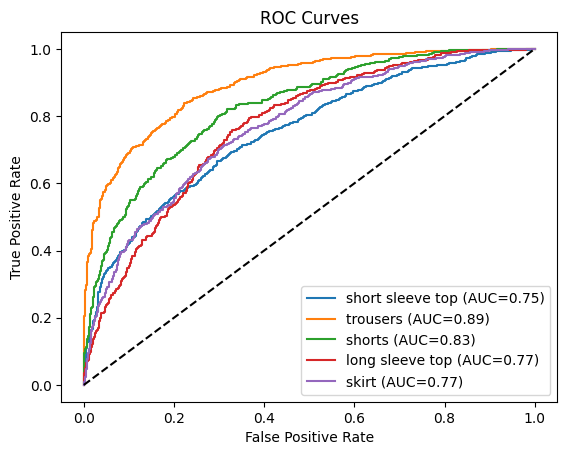

(0.609011420905923,
 0.6333333333333333,
 {'short sleeve top': np.float64(0.752735023445924),
  'trousers': np.float64(0.8937682520955772),
  'shorts': np.float64(0.8279599904505113),
  'long sleeve top': np.float64(0.770268391044361),
  'skirt': np.float64(0.7705002598752598)})

In [35]:
print("\n===== SCRATCH MODEL =====")
evaluate_full(model_scratch, val_loader)

In [30]:
for param in model.features.parameters():
    param.requires_grad = False

Transfer Learning

In [31]:
import torch.optim as optim

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

In [36]:
for epoch in range(15):
    loss = train_epoch(model, train_loader)
    f1   = evaluate(model, val_loader)

    print(f"[TL] Epoch {epoch}: Loss={loss:.4f}, F1={f1:.4f}")

[TL] Epoch 0: Loss=0.7510, F1=0.5695
[TL] Epoch 1: Loss=0.7292, F1=0.5857
[TL] Epoch 2: Loss=0.7075, F1=0.5877
[TL] Epoch 3: Loss=0.6844, F1=0.5804
[TL] Epoch 4: Loss=0.6618, F1=0.5977
[TL] Epoch 5: Loss=0.6370, F1=0.5942
[TL] Epoch 6: Loss=0.6176, F1=0.6006
[TL] Epoch 7: Loss=0.6046, F1=0.5944
[TL] Epoch 8: Loss=0.5867, F1=0.6014
[TL] Epoch 9: Loss=0.5680, F1=0.5856
[TL] Epoch 10: Loss=0.5418, F1=0.5954
[TL] Epoch 11: Loss=0.5305, F1=0.6052
[TL] Epoch 12: Loss=0.5165, F1=0.6055
[TL] Epoch 13: Loss=0.5033, F1=0.5880
[TL] Epoch 14: Loss=0.4880, F1=0.5934


In [39]:
import numpy as np
import torch
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu().numpy()

            all_preds.append(outputs)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # -------------------------------
    # 1. Classification Report
    # -------------------------------
    print("\n=== Classification Report ===")
    print(classification_report(all_labels, preds_binary, target_names=list(label_map.keys())))

    # -------------------------------
    # 2. Macro & Micro F1
    # -------------------------------
    macro_f1 = f1_score(all_labels, preds_binary, average="macro")
    micro_f1 = f1_score(all_labels, preds_binary, average="micro")

    print(f"\nMacro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")

    # -------------------------------
    # 3. ROC + AUC per class
    # -------------------------------
    print("\n=== AUC per class ===")

    auc_scores = {}

    for i, class_name in enumerate(label_map.keys()):
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores[class_name] = auc
            print(f"{class_name}: AUC = {auc:.4f}")

            # Plot ROC
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")

        except:
            print(f"{class_name}: AUC not defined")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    return macro_f1, micro_f1, auc_scores


===== TRANSFER LEARNING =====

=== Classification Report ===
                  precision    recall  f1-score   support

short sleeve top       0.70      0.69      0.70      1055
        trousers       0.78      0.69      0.73       803
          shorts       0.36      0.74      0.48       344
 long sleeve top       0.45      0.54      0.49       470
           skirt       0.47      0.70      0.57       520

       micro avg       0.57      0.68      0.62      3192
       macro avg       0.55      0.67      0.59      3192
    weighted avg       0.61      0.68      0.63      3192
     samples avg       0.59      0.68      0.60      3192


Macro F1: 0.5934
Micro F1: 0.6173

=== AUC per class ===
short sleeve top: AUC = 0.7547
trousers: AUC = 0.8578
shorts: AUC = 0.8026
long sleeve top: AUC = 0.7413
skirt: AUC = 0.7937


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


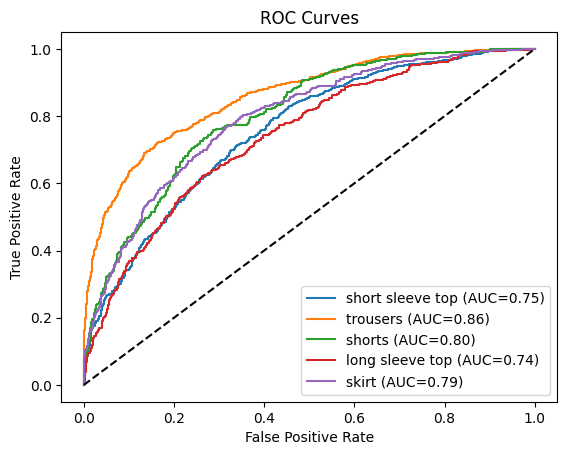

(0.5934155678420534,
 0.6172980700500358,
 {'short sleeve top': np.float64(0.7547120038115298),
  'trousers': np.float64(0.8578034958712681),
  'shorts': np.float64(0.8025853836647568),
  'long sleeve top': np.float64(0.7413377833402865),
  'skirt': np.float64(0.793653846153846)})

In [42]:
print("\n===== TRANSFER LEARNING =====")
model_tl = model
evaluate_full(model_tl, val_loader)

Fine Tuning

In [43]:
for param in model.parameters():
    param.requires_grad = True

In [46]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [47]:
for epoch in range(15):
    loss = train_epoch(model, train_loader)
    f1   = evaluate(model, val_loader)

    print(f"[FT] Epoch {epoch}: Loss={loss:.4f}, F1={f1:.4f}")

[FT] Epoch 0: Loss=0.4067, F1=0.6214
[FT] Epoch 1: Loss=0.3499, F1=0.6265
[FT] Epoch 2: Loss=0.3146, F1=0.6267
[FT] Epoch 3: Loss=0.2893, F1=0.6450
[FT] Epoch 4: Loss=0.2692, F1=0.6368
[FT] Epoch 5: Loss=0.2483, F1=0.6329
[FT] Epoch 6: Loss=0.2291, F1=0.6306
[FT] Epoch 7: Loss=0.2146, F1=0.6369
[FT] Epoch 8: Loss=0.2014, F1=0.6454
[FT] Epoch 9: Loss=0.1871, F1=0.6453
[FT] Epoch 10: Loss=0.1740, F1=0.6458
[FT] Epoch 11: Loss=0.1623, F1=0.6529
[FT] Epoch 12: Loss=0.1483, F1=0.6535
[FT] Epoch 13: Loss=0.1419, F1=0.6573
[FT] Epoch 14: Loss=0.1305, F1=0.6491


In [48]:
import numpy as np
import torch
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu().numpy()

            all_preds.append(outputs)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Binary predictions
    preds_binary = (all_preds > 0.5).astype(int)

    # -------------------------------
    # 1. Classification Report
    # -------------------------------
    print("\n=== Classification Report ===")
    print(classification_report(all_labels, preds_binary, target_names=list(label_map.keys())))

    # -------------------------------
    # 2. Macro & Micro F1
    # -------------------------------
    macro_f1 = f1_score(all_labels, preds_binary, average="macro")
    micro_f1 = f1_score(all_labels, preds_binary, average="micro")

    print(f"\nMacro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")

    # -------------------------------
    # 3. ROC + AUC per class
    # -------------------------------
    print("\n=== AUC per class ===")

    auc_scores = {}

    for i, class_name in enumerate(label_map.keys()):
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores[class_name] = auc
            print(f"{class_name}: AUC = {auc:.4f}")

            # Plot ROC
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")

        except:
            print(f"{class_name}: AUC not defined")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    return macro_f1, micro_f1, auc_scores


===== FINE-TUNING =====

=== Classification Report ===
                  precision    recall  f1-score   support

short sleeve top       0.74      0.71      0.73      1055
        trousers       0.79      0.81      0.80       803
          shorts       0.50      0.64      0.56       344
 long sleeve top       0.60      0.47      0.53       470
           skirt       0.70      0.57      0.63       520

       micro avg       0.70      0.67      0.68      3192
       macro avg       0.67      0.64      0.65      3192
    weighted avg       0.70      0.67      0.68      3192
     samples avg       0.68      0.68      0.66      3192


Macro F1: 0.6491
Micro F1: 0.6841

=== AUC per class ===
short sleeve top: AUC = 0.7999
trousers: AUC = 0.9161
shorts: AUC = 0.8611
long sleeve top: AUC = 0.7902
skirt: AUC = 0.8584


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


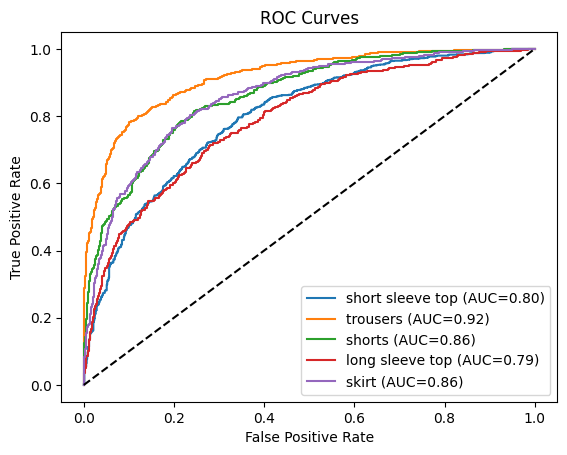

(0.6490554508497153,
 0.6840672538030425,
 {'short sleeve top': np.float64(0.7999202587828181),
  'trousers': np.float64(0.916119689010821),
  'shorts': np.float64(0.8611163773733289),
  'long sleeve top': np.float64(0.790239187873731),
  'skirt': np.float64(0.8583848752598753)})

In [49]:
print("\n===== FINE-TUNING =====")
model_ft = model
evaluate_full(model_ft, val_loader)

In [ ]:
torch.save(model.state_dict(), "mobilenet_best.pth")

In [ ]:
from sklearn.metrics import classification_report

model.eval()
preds, targets = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu()

        preds.append(outputs)
        targets.append(labels)

preds = torch.cat(preds).numpy()
targets = torch.cat(targets).numpy()

preds = (preds > 0.5).astype(int)

print(classification_report(targets, preds, target_names=list(label_map.keys())))

In [ ]:
torch.save(model.state_dict(), "mobilenet_best.pth")

In [ ]:
def get_model():
    import torch.nn as nn
    from torchvision import models

    model = models.mobilenet_v3_small(pretrained=False)

    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 5)

    return model

In [ ]:
def predict(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = torch.sigmoid(model(image)).cpu().numpy()[0]

    preds = (outputs > 0.5).astype(int)

    return preds